In [43]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from astropy import units as u
from astropy import coordinates as coord
from astropy.time import Time

In [4]:
artemis2_data = np.loadtxt('Artemis_II_OEM_2026_04_02_to_EI_v3.asc', dtype='str', delimiter=' ', skiprows=20)
artemis2_data

array([['2026-04-02T03:07:49.583', '-29508.961014802717',
        '-25381.215441259497', ..., '-0.72424023033391',
        '-2.66808196805166', '-1.44111053615681'],
       ['2026-04-02T03:09:34.583', '-29584.090239275465',
        '-25660.573915092162', ..., '-0.70684323094235',
        '-2.65305448826716', '-1.43295930829273'],
       ['2026-04-02T03:11:19.583', '-29657.408571126169',
        '-25938.361600861073', ..., '-0.68974560926973',
        '-2.63816178360159', '-1.42488155818947'],
       ...,
       ['2026-04-10T23:45:12.332', '7481.776466339368',
        '2586.400660587075', ..., '-5.84028126438460',
        '5.44492585416367', '5.89301838688603'],
       ['2026-04-10T23:49:12.332', '5899.436102827137',
        '3814.271401033587', ..., '-7.37843329294763',
        '4.69529866396621', '5.90521309889616'],
       ['2026-04-10T23:53:12.332', '3939.274355868496',
        '4790.333100554099', ..., '-8.91556528978230',
        '3.33417910527999', '5.48458760843818']],
      sha

In [12]:
artemis2_t = artemis2_data[:, 0].astype(np.datetime64)
artemis2_t

array(['2026-04-02T03:07:49.583', '2026-04-02T03:09:34.583',
       '2026-04-02T03:11:19.583', ..., '2026-04-10T23:45:12.332',
       '2026-04-10T23:49:12.332', '2026-04-10T23:53:12.332'],
      shape=(3212,), dtype='datetime64[ms]')

In [22]:
artemis2_coords = artemis2_data[:, 1:4].astype(np.float64)
artemis2_coords

array([[-29508.9610148 , -25381.21544126, -13766.61073866],
       [-29584.09023928, -25660.57391509, -13917.49875662],
       [-29657.40857113, -25938.36160086, -14067.53476509],
       ...,
       [  7481.77646634,   2586.40066059,   -806.69703039],
       [  5899.43610283,   3814.27140103,    615.52082985],
       [  3939.27435587,   4790.33310055,   1992.87915533]],
      shape=(3212, 3))

In [25]:
artemis2_speeds = artemis2_data[:, 4:].astype(np.float64)
artemis2_speeds

array([[-0.72424023, -2.66808197, -1.44111054],
       [-0.70684323, -2.65305449, -1.43295931],
       [-0.68974561, -2.63816178, -1.42488156],
       ...,
       [-5.84028126,  5.44492585,  5.89301839],
       [-7.37843329,  4.69529866,  5.9052131 ],
       [-8.91556529,  3.33417911,  5.48458761]], shape=(3212, 3))

In [33]:
artemis2_abs_speeds = np.linalg.norm(artemis2_speeds, axis=1).reshape(-1, 1)
artemis2_abs_speeds

array([[ 3.11768903],
       [ 3.09704663],
       [ 3.07667581],
       ...,
       [ 9.92389886],
       [10.55266076],
       [10.98566138]], shape=(3212, 1))

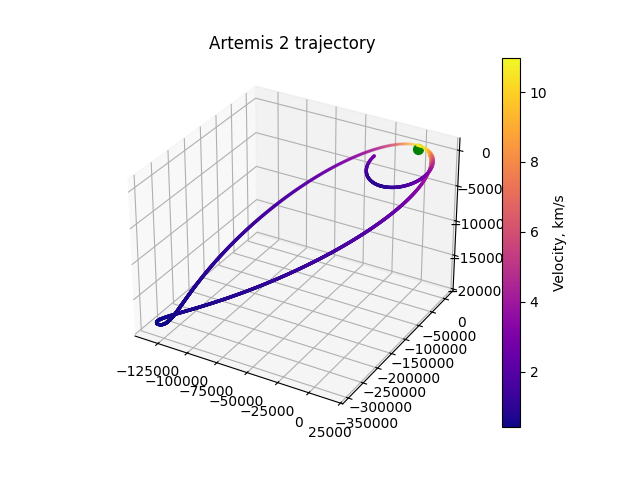

In [40]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
trajectory_scatter = ax.scatter(
    artemis2_coords[:, 0],
    artemis2_coords[:, 1],
    artemis2_coords[:, 2],
    s=2,
    c=artemis2_abs_speeds,
    cmap='plasma',
)
fig.colorbar(trajectory_scatter, orientation='vertical').set_label('Velocity, km/s')
ax.scatter(0, 0, 0, c='green', s=50)
ax.set_title('Artemis 2 trajectory')
plt.show()

In [57]:
moon_artemis2_coords = coord.get_body('moon', Time(artemis2_t))
moon_artemis2_coords

<SkyCoord (GCRS: obstime=['2026-04-02T03:07:49.583000000' '2026-04-02T03:09:34.583000000'
 '2026-04-02T03:11:19.583000000' ... '2026-04-10T23:45:12.332000000'
 '2026-04-10T23:49:12.332000000' '2026-04-10T23:53:12.332000000'], obsgeoloc=(0., 0., 0.) m, obsgeovel=(0., 0., 0.) m / s): (ra, dec, distance) in (deg, deg, AU)
    [(190.32712227,  -7.61114753, 0.00263189),
     (190.34085471,  -7.6181896 , 0.00263192),
     (190.35458731,  -7.62523108, 0.00263195), ...,
     (302.43345762, -23.36870427, 0.00265374),
     (302.4690754 , -23.35907925, 0.00265366),
     (302.5046902 , -23.34944558, 0.00265358)]>

In [58]:
moon_artemis2_coords = moon_artemis2_coords.represent_as('cartesian')
moon_artemis2_coords

<CartesianRepresentation (x, y, z) in AU
    [(-0.00256645, -0.00046766, -0.00034859),
     (-0.00256632, -0.00046827, -0.00034892),
     (-0.00256619, -0.00046888, -0.00034924), ...,
     ( 0.00130651, -0.00205607, -0.0010526 ),
     ( 0.00130784, -0.00205535, -0.00105216),
     ( 0.00130917, -0.00205462, -0.00105172)]>

In [59]:
moon_artemis2_coords = np.array([
    moon_artemis2_coords.x.to_value(u.km),
    moon_artemis2_coords.y.to_value(u.km),
    moon_artemis2_coords.z.to_value(u.km)
])
moon_artemis2_coords

array([[-383934.90145848, -383915.8023091 , -383896.67551629, ...,
         195450.62169922,  195650.11148212,  195849.52854254],
       [ -69960.55966566,  -70052.15436128,  -70143.74401555, ...,
        -307583.74276273, -307475.25560518, -307366.65343685],
       [ -52148.67737166,  -52197.18462281,  -52245.68808878, ...,
        -157466.35811999, -157400.40623053, -157334.39548348]],
      shape=(3, 3212))

In [60]:
moon_artemis2_coords = moon_artemis2_coords.T
moon_artemis2_coords

array([[-383934.90145848,  -69960.55966566,  -52148.67737166],
       [-383915.8023091 ,  -70052.15436128,  -52197.18462281],
       [-383896.67551629,  -70143.74401555,  -52245.68808878],
       ...,
       [ 195450.62169922, -307583.74276273, -157466.35811999],
       [ 195650.11148212, -307475.25560518, -157400.40623053],
       [ 195849.52854254, -307366.65343685, -157334.39548348]],
      shape=(3212, 3))

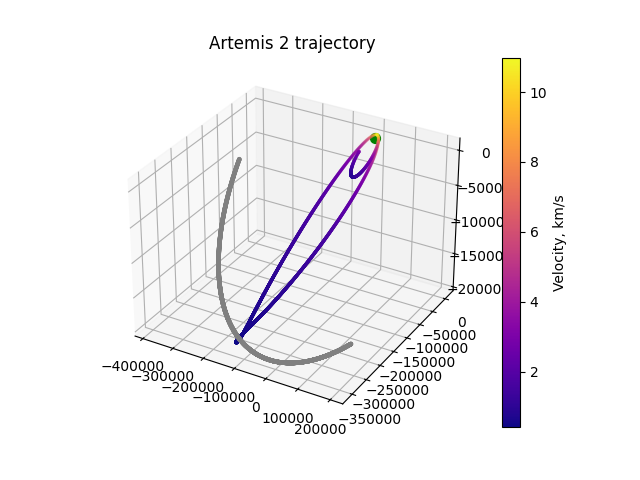

In [61]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
trajectory_scatter = ax.scatter(
    artemis2_coords[:, 0],
    artemis2_coords[:, 1],
    artemis2_coords[:, 2],
    s=2,
    c=artemis2_abs_speeds,
    cmap='plasma',
)
fig.colorbar(trajectory_scatter, orientation='vertical').set_label('Velocity, km/s')
moon_scatter = ax.scatter(
    moon_artemis2_coords[:, 0],
    moon_artemis2_coords[:, 1],
    moon_artemis2_coords[:, 2],
    s=5,
    c='gray',
)
ax.scatter(0, 0, 0, c='green', s=50)
ax.set_title('Artemis 2 trajectory')
plt.show()

In [41]:
artemis1_data = np.loadtxt('Post_TLI_Orion_AsFlown_20221213_EPH_OEM.asc', dtype='str', delimiter=' ', skiprows=20)

artemis1_t = artemis1_data[:, 0].astype(np.datetime64)
artemis1_coords = artemis1_data[:, 1:4].astype(np.float64)
artemis1_speeds = artemis1_data[:, 4:].astype(np.float64)
artemis1_abs_speeds = np.linalg.norm(artemis1_speeds, axis=1).reshape(-1, 1)

In [62]:
moon_artemis1_coords = coord.get_body('moon', Time(artemis1_t))
moon_artemis1_coords = moon_artemis1_coords.represent_as('cartesian')
moon_artemis1_coords = np.array([
    moon_artemis1_coords.x.to_value(u.km),
    moon_artemis1_coords.y.to_value(u.km),
    moon_artemis1_coords.z.to_value(u.km)
])
moon_artemis1_coords = moon_artemis1_coords.T
moon_artemis1_coords

array([[-313367.21733108,  214244.075573  ,  132733.99224285],
       [-313506.73970229,  214074.28143313,  132656.2278548 ],
       [-313646.14926676,  213904.41038088,  132578.41578271],
       ...,
       [-191196.39992915,  312710.35587981,  174156.81835347],
       [-191401.35183382,  312607.61919518,  174117.93977742],
       [-191606.23627598,  312504.77509963,  174079.00113727]],
      shape=(9211, 3))

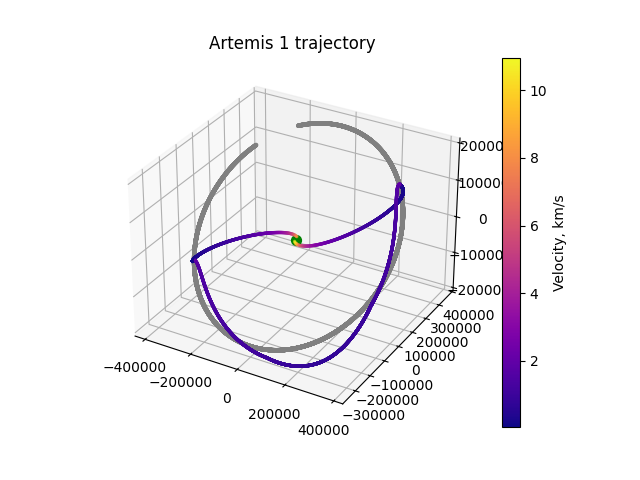

In [63]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
trajectory_scatter = ax.scatter(
    artemis1_coords[:, 0],
    artemis1_coords[:, 1],
    artemis1_coords[:, 2],
    s=2,
    c=artemis1_abs_speeds,
    cmap='plasma',
)
fig.colorbar(trajectory_scatter, orientation='vertical').set_label('Velocity, km/s')
moon_scatter = ax.scatter(
    moon_artemis1_coords[:, 0],
    moon_artemis1_coords[:, 1],
    moon_artemis1_coords[:, 2],
    s=5,
    c='gray',
)
ax.scatter(0, 0, 0, c='green', s=50)
ax.set_title('Artemis 1 trajectory')
plt.show()